<a href="https://colab.research.google.com/github/kreaja/TrialRepositoryJustForMe/blob/main/hw02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW02: Text Processing & BPE
## CIS 5300: Natural Language Processing | Module 02 | 100 Points

---

### Overview

In this assignment, you will work through the core text processing pipeline: **regular expressions**, **tokenization**, **text normalization**, and **subword tokenization with Byte-Pair Encoding (BPE)**. You will implement BPE from scratch, then compare your implementation to a production tokenizer used by GPT-4.

This homework connects directly to the Module 02 material:
- **Regular Expressions:** Regex Basics, Regex in Practice, Tokenization with Regex
- **Tokenization:** Word Tokenization, NLTK and Practical Tokenizers
- **Stemming & Lemmatization:** Stemming, Lemmatization, Normalization Tradeoffs
- **BPE & Subword Tokenization:** BPE Algorithm, Subword Vocabulary, Multilingual Tokenization Bias

**Textbook Reference:** [Chapter 2: Words and Tokens](https://web.stanford.edu/~jurafsky/slp3/2.pdf) of *Speech and Language Processing* (https://web.stanford.edu/~jurafsky/slp3/) by Jurafsky & Martin.

### Point Breakdown

| Section | Topic | Points | Type |
|---------|-------|--------|------|
| 0 | Setup | 0 | -- |
| 1 | Regular Expressions | 15 | Code (autograded) + Writeup |
| 2 | Tokenization | 20 | Code (autograded) |
| 3 | Text Normalization | 10 | Code (autograded) + Writeup |
| 4 | Byte-Pair Encoding | 35 | Code (autograded) |
| 5 | Modern Tokenizers | 10 | Code + Writeup |
| 6 | Reflection | 10 | Writeup |
| **Total** | | **100** | |

### Deliverables

Submit the following to Gradescope:

| File | Description |
|------|-------------|
| `hw02.ipynb` | This notebook with all code cells completed |
| `hw02.py` | The code from this notebook saved as a .py file      |
| `hw02_writeup.pdf` | Written answers to all questions marked **[WRITEUP]** |

### Recommended Reading

- [Chapter 2: Regular Expressions, Text Normalization, Edit Distance](https://web.stanford.edu/~jurafsky/slp3/2.pdf) -- Jurafsky & Martin, SLP 3rd Edition
- Module 02 Lecture Series

---
## Section 0: Setup (0 points)

Run the following cells to install dependencies and load the data. **Do not modify these cells.**

In [1]:
# How do I tell Colab to use a Python 3.12 version? 3.13+ might break Pickler._batch_setitems()
#%pip install gcsfs==2025.3.0 fsspec==2025.3.0

%pip install matplotlib
# Pin datasets==3.6.0 — newer versions removed script-based loaders
# that are needed for the Wikipedia dataset!
#%pip install -q numpy nltk tiktoken syllables 'datasets==3.6.0'
#%pip install dill==0.3.8
# I think this notebook means for us to use dill 3.something, not 4.x


In [2]:
import re
import string
import copy
from collections import Counter, defaultdict
import sys
import numpy as np
import nltk
import tiktoken

# Download required NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

print("All imports successful.")

All imports successful.


In [3]:
# Wikipedia dataset load
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        ########## DO NOT MODIFY ##########
        # Load the Simple English Wikipedia dataset
        #
        # We use a subset of Simple English Wikipedia, which is written in
        # simplified English. This gives us a corpus with relatively common
        # vocabulary that is manageable in size.

        from datasets import load_dataset

        print("Loading Simple English Wikipedia dataset...")
        print("(This may take a minute on first run as it downloads the data.)")

        # Loading the Simple English Wikipedia dataset (2023-11-01 snapshot)
        dataset = load_dataset("wikimedia/wikipedia", "20231101.simple", split="train")

        # Use first 5000 articles for manageable size
        NUM_ARTICLES = 5000
        corpus_docs = [doc['text'] for doc in dataset.select(range(NUM_ARTICLES))]

        print(f"Loaded {len(corpus_docs)} documents.")
        print(f"Total characters: {sum(len(d) for d in corpus_docs):,}")
        print(f"\nFirst 200 characters of document 0:")
        print(corpus_docs[0][:200])
    except Exception as e:
        print(f"\u26a0\ufe0f  Wikipedia dataset load skipped: {type(e).__name__}: {e}")
        corpus_docs = []

Loading Simple English Wikipedia dataset...
(This may take a minute on first run as it downloads the data.)


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.simple/train-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  157MB            

20231101.simple/train-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/241787 [00:00<?, ? examples/s]

Loaded 5000 documents.
Total characters: 21,214,599

First 200 characters of document 0:
April (Apr.) is the fourth month of the year in the Julian and Gregorian calendars, and comes between March and May. It is one of the four months to have 30 days.

April always begins on the same day 


---
## Section 1: Regular Expressions (15 points)

Regular expressions are a fundamental tool for text processing. In this section, you will practice the three most common `re` module functions: `re.search()`, `re.findall()`, and `re.sub()`.

**Lectures:** M02.1.1-M02.1.3 | **Textbook:** Chapter 2, Section 2.1

**Important:** Always use raw strings for regex patterns (prefix with `r`). For example, write `r'\bword\b'` instead of `'\\bword\\b'`. Raw strings prevent Python from interpreting backslashes as escape characters before the regex engine sees them.

### Problem 1.1: `re.search` -- Pattern Matching (4 points)

Write a function that uses `re.search()` to check if a word contains a specific vowel pattern.

Specifically, return `True` if the word contains the letter **'o' repeated 2 or more times consecutively** (e.g., "food", "voodoo", "ooze"), and `False` otherwise.

**The match should be case-insensitive** (e.g., `has_double_o("OOZE")` should return `True`).

**Worked example:**
```
has_double_o("food")    -> True   # contains "oo"
has_double_o("foot")    -> True   # contains "oo"
has_double_o("outdoor") -> True   # contains "oo" inside "door"
has_double_o("voodoo")  -> True   #
has_double_o("fox")     -> False  # only one 'o'
has_double_o("potato")  -> False  # two o's but not consecutive
```


In [4]:
import datasets
print(datasets.__version__)

def has_double_o(word: str) -> bool:
    """Check if a word contains two or more consecutive 'o' characters.

    Uses re.search() with a pattern that matches 'o' repeated 2+ times.
    Case-insensitive.

    Args:
        word: A string to check.

    Returns:
        True if the word contains 'oo' (or 'ooo', etc.), False otherwise.
    """
    # SYNTAX: re.search(pattern, string)
    return bool(re.search(r"oo", word, re.IGNORECASE))

4.8.5


In [5]:
# Sanity checks
assert has_double_o("food") == True, "'food' contains 'oo'"
assert has_double_o("foot") == True, "'foot' contains 'oo'"
assert has_double_o("outdoor") == True, "'outdoor' contains 'oo' inside 'door'"
assert has_double_o("voodoo") == True, "'voodoo' contains 'oo'"
assert has_double_o("OOZE") == True, "Should be case-insensitive"
assert has_double_o("fox") == False, "'fox' has only one 'o'"
assert has_double_o("potato") == False, "'potato' has two o's but they are not consecutive"
assert has_double_o("") == False, "Empty string has no 'oo'"

print("All sanity checks passed!")


All sanity checks passed!


### Problem 1.2: `re.findall` -- Extract Email Addresses (4 points)

Write a function that uses `re.findall()` to extract all email addresses from a text string.

For this exercise, an email address follows the pattern: `username@domain.tld` where:
- **username** consists of one or more word characters (letters, digits, underscores) and may contain dots or hyphens
- **domain** consists of one or more word characters, may contain dots or hyphens
- **tld** (top-level domain) is 2-4 letters (e.g., `com`, `edu`, `org`, `info`)

**Tip:** test your regex incrementally on the examples below — start with a pattern that matches a single simple email, then extend it to handle dots, hyphens, and underscores.

**Worked example:**
```
text = "Contact us at support@example.com or john.doe@university.edu for help."
extract_emails(text) -> ['support@example.com', 'john.doe@university.edu']
```


In [6]:
def extract_emails(text: str) -> list:
    """Extract all email addresses from the given text.

    Uses re.findall() to find all substrings matching an email pattern.

    Args:
        text: A string that may contain email addresses.

    Returns:
        A list of strings, each an email address found in the text.
    """
    # SYNTAX: re.findall(pattern, string)
    return re.findall(r"[\w.-]+@[\w.-]+\.[A-Za-z]{2,4}", text)


In [7]:
# Sanity checks
text1 = "Contact us at support@example.com or john.doe@university.edu for help."
assert extract_emails(text1) == ['support@example.com', 'john.doe@university.edu'], \
    f"Expected two emails, got {extract_emails(text1)}"

text2 = "No emails here!"
assert extract_emails(text2) == [], "Should return empty list when no emails found"

text3 = "Email me at alice_99@mail-server.info"
assert extract_emails(text3) == ['alice_99@mail-server.info'], \
    f"Should handle underscores and hyphens: got {extract_emails(text3)}"

print("All sanity checks passed!")

All sanity checks passed!


### Problem 1.3: `re.sub` -- Date Format Replacement (4 points)

Write a function that uses `re.sub()` to convert dates from **MM/DD/YYYY** format to **YYYY-MM-DD** (ISO 8601) format.

The function should find all dates in the format `MM/DD/YYYY` (where MM is 01-12, DD is 01-31, YYYY is a 4-digit year) and replace them with `YYYY-MM-DD`.

**Hint:** Use capturing groups `()` in your pattern and backreferences `\1`, `\2`, `\3` in your replacement string.

**Worked example:**
```
text = "The meeting is on 03/15/2026 and the deadline is 12/01/2025."
reformat_dates(text) -> "The meeting is on 2026-03-15 and the deadline is 2025-12-01."
```

In [8]:
def reformat_dates(text: str) -> str:
    """Convert all dates from MM/DD/YYYY to YYYY-MM-DD format.

    Uses re.sub() with capturing groups to rearrange date components.

    Args:
        text: A string that may contain dates in MM/DD/YYYY format.

    Returns:
        The text with all MM/DD/YYYY dates converted to YYYY-MM-DD.
    """
    # SYNTAX: re.sub(pattern_to_find, replacement, string)
    # Now we finally get to use capturing groups.

    return re.sub(r"(0[1-9]|1[012])/(0[1-9]|[12]\d|3[01])/(\d{4})", r"\3-\1-\2", text)

In [9]:
# Sanity checks
text1 = "The meeting is on 03/15/2026 and the deadline is 12/01/2025."
expected1 = "The meeting is on 2026-03-15 and the deadline is 2025-12-01."
assert reformat_dates(text1) == expected1, f"Got: {reformat_dates(text1)}"

text2 = "No dates here."
assert reformat_dates(text2) == text2, "Text without dates should be unchanged"

text3 = "Born on 07/04/1776."
assert reformat_dates(text3) == "Born on 1776-07-04.", f"Got: {reformat_dates(text3)}"

print("All sanity checks passed!")

All sanity checks passed!


### [WRITEUP] Answer 1: Regex Design Challenge (3 points)

Design a regex to **extract URLs** from text. Your regex should handle `http://` and `https://` URLs with paths and query parameters.

In your writeup:
1. Show your regex pattern
2. Give **3 example URLs** that your regex correctly matches
3. Give **2 example URLs** (or URL-like strings) that your regex **fails** on or incorrectly matches

*(Hint: Try your regex on strings like `https://example.com/path?q=1&r=2`, `http://sub.domain.co.uk/page`, and edge cases like URLs in parentheses or followed by punctuation.)*

---
## Section 2: Tokenization (20 points)

Tokenization is the first step in almost every NLP pipeline: splitting raw text into a sequence of tokens. In this section you will implement two tokenizers from scratch and then use NLTK's tokenizer, comparing how each handles tricky edge cases.

**Lectures:** M02.1.4-M02.1.5 | **Textbook:** Chapter 2, Section 2.4

In [10]:
########## DO NOT MODIFY ##########
# Sample text for tokenization exercises
sample_text = """Dr. Smith's appointment is at 3:30 p.m. on 01/15/2026.
She'll bring the state-of-the-art x-ray results (including the $45.99 co-pay receipt).
Contact: dr.smith@hospital.org or call 555-1234.
"It's not rocket science," she said -- but NLP tokenization isn't trivial either!"""

print("Sample text:")
print(sample_text)

Sample text:
Dr. Smith's appointment is at 3:30 p.m. on 01/15/2026.
She'll bring the state-of-the-art x-ray results (including the $45.99 co-pay receipt).
Contact: dr.smith@hospital.org or call 555-1234.
"It's not rocket science," she said -- but NLP tokenization isn't trivial either!


### Problem 2.1: Whitespace Tokenizer (5 points)

Implement the simplest possible tokenizer: split text on whitespace. This is a useful baseline for comparison.

**Expected behavior:**
```
whitespace_tokenize("Hello world!")  ->  ["Hello", "world!"]
whitespace_tokenize("  extra   spaces  ")  ->  ["extra", "spaces"]
```

Note that punctuation stays attached to words -- this is the main limitation of whitespace tokenization.

In [11]:
def whitespace_tokenize(text: str) -> list:
    """Tokenize text by splitting on whitespace.

    Args:
        text: A string to tokenize.

    Returns:
        A list of tokens (strings), split on whitespace. Empty tokens
        from multiple consecutive spaces should not be included.
    """
    ## The default Python `split` behavior greedily eats whitespace, so
    return text.split()

In [12]:
# Sanity checks
assert whitespace_tokenize("Hello world!") == ["Hello", "world!"], \
    "Basic whitespace split failed"
assert whitespace_tokenize("  extra   spaces  ") == ["extra", "spaces"], \
    "Multiple spaces should not produce empty tokens"
assert whitespace_tokenize("") == [], "Empty string should produce empty list"

ws_tokens = whitespace_tokenize(sample_text)
print(f"Whitespace tokenizer: {len(ws_tokens)} tokens")
print(f"First 10 tokens: {ws_tokens[:10]}")
print(f"\nNotice: punctuation stays attached to words (e.g., 'p.m.', '2026.', 'receipt).')")
print("All sanity checks passed!")

Whitespace tokenizer: 38 tokens
First 10 tokens: ['Dr.', "Smith's", 'appointment', 'is', 'at', '3:30', 'p.m.', 'on', '01/15/2026.', "She'll"]

Notice: punctuation stays attached to words (e.g., 'p.m.', '2026.', 'receipt).')
All sanity checks passed!


### Problem 2.2: Improved Tokenizer (8 points)

Implement a better tokenizer that **separates all punctuation from words**. Your tokenizer should:

1. Split text on whitespace (like Problem 2.1)
2. For each token, separate any leading or trailing punctuation characters into their own tokens

Use `not ch.isalnum()` to detect punctuation characters (this catches all non-alphanumeric characters including periods, commas, parentheses, quotes, etc.).

**Important edge cases to be aware of:** This simple approach will split contractions ("don't" -> ["don", "'", "t"]), hyphenated words ("state-of-the-art" -> ["state", "-", "of", "-", "the", "-", "art"]), and numbers with decimals ("$45.99" -> ["$", "45", ".", "99"]). That is OK for this exercise -- the goal is to understand why smarter tokenizers are needed.

**Worked example:**
```
improved_tokenize("Hello, world!") -> ["Hello", ",", "world", "!"]
improved_tokenize("(test)")        -> ["(", "test", ")"]
```

In [13]:
def improved_tokenize(text: str) -> list:
    """Tokenize text by splitting on whitespace and separating punctuation.

    For each whitespace-delimited token, separate leading and trailing
    non-alphanumeric characters into their own tokens. Interior punctuation
    (e.g., hyphens in 'state-of-the-art', apostrophes in "don't") should
    also be separated.

    Args:
        text: A string to tokenize.

    Returns:
        A list of tokens with punctuation separated. Empty tokens should
        not be included.
    """
    list_o_tokes = re.findall(r"[A-Za-z0-9]+|[^A-Za-z0-9\s]", text)  # A string of alphanumeric characters, or a punctuation mark
    return list_o_tokes

In [14]:
# Sanity checks
assert improved_tokenize("Hello, world!") == ["Hello", ",", "world", "!"], \
    f"Got: {improved_tokenize('Hello, world!')}"
assert improved_tokenize("(test)") == ["(", "test", ")"], \
    f"Got: {improved_tokenize('(test)')}"
assert improved_tokenize("") == [], "Empty string should produce empty list"

imp_tokens = improved_tokenize(sample_text)
print(f"Improved tokenizer: {len(imp_tokens)} tokens")
print(f"First 15 tokens: {imp_tokens[:15]}")
print(f"\nNotice how punctuation is now separated, but contractions and")
print(f"hyphenated words are also split. Compare to NLTK in Problem 2.3.")
print("All sanity checks passed!")

Improved tokenizer: 88 tokens
First 15 tokens: ['Dr', '.', 'Smith', "'", 's', 'appointment', 'is', 'at', '3', ':', '30', 'p', '.', 'm', '.']

Notice how punctuation is now separated, but contractions and
hyphenated words are also split. Compare to NLTK in Problem 2.3.
All sanity checks passed!


### Problem 2.3: NLTK Tokenizer + Preprocessing (7 points)

Now use NLTK's `word_tokenize()` and apply standard text preprocessing:
1. Tokenize the text using `nltk.word_tokenize()`
2. Lowercase all tokens
3. Remove stopwords (using `nltk.corpus.stopwords.words('english')`)
4. Keep only tokens that are **alphabetic** (use `str.isalpha()`)

This preprocessed tokenizer will be used as the basis for our BPE experiments in Section 4.

**Note:** `word_tokenize()` handles contractions more intelligently (e.g., "don't" -> ["do", "n't"]) and keeps abbreviations together. Compare its output to your improved tokenizer.

In [15]:
def nltk_preprocess(text: str) -> list:
    """Tokenize and preprocess text using NLTK.

    Steps:
        1. Tokenize with nltk.word_tokenize()
        2. Lowercase all tokens
        3. Remove English stopwords
        4. Keep only alphabetic tokens (str.isalpha())

    Args:
        text: A string to tokenize and preprocess.

    Returns:
        A list of preprocessed tokens (lowercase, no stopwords, alphabetic only).
    """
    word_tokenized = nltk.word_tokenize(text)
    word_tokenized = [wo.lower() for wo in word_tokenized]
    NLTK_STOPWORDS = set(stopwords.words('english'))  # We make a set of the
    # English-language stopwords because later parts were running too slowly
    go_words = [wrd for wrd in word_tokenized if wrd not in NLTK_STOPWORDS]
    alphabetic = [wrd for wrd in go_words if str.isalpha(wrd)]
    return alphabetic

In [16]:
# Sanity checks
test_result = nltk_preprocess("The quick brown fox jumps over the lazy dog.")
# 'the' and 'over' are stopwords; '.' is not alphabetic
assert "the" not in test_result, "Stopwords should be removed"
assert "over" not in test_result, "Stopwords should be removed"
assert "." not in test_result, "Non-alphabetic tokens should be removed"
assert "quick" in test_result, "'quick' should be in the result"
assert all(t == t.lower() for t in test_result), "All tokens should be lowercase"

nltk_tokens = nltk_preprocess(sample_text)
print(f"NLTK preprocessed: {len(nltk_tokens)} tokens")
print(f"First 15 tokens: {nltk_tokens[:15]}")

# Compare all three tokenizers
print(f"\n--- Tokenizer Comparison ---")
print(f"Whitespace:  {len(ws_tokens)} tokens")
print(f"Improved:    {len(imp_tokens)} tokens")
print(f"NLTK preproc: {len(nltk_tokens)} tokens (after stopword removal & filtering)")
print("All sanity checks passed!")

NLTK preprocessed: 15 tokens
First 15 tokens: ['smith', 'appointment', 'bring', 'results', 'including', 'receipt', 'contact', 'call', 'rocket', 'science', 'said', 'nlp', 'tokenization', 'trivial', 'either']

--- Tokenizer Comparison ---
Whitespace:  38 tokens
Improved:    88 tokens
NLTK preproc: 15 tokens (after stopword removal & filtering)
All sanity checks passed!


---
## Section 3: Text Normalization (10 points)

Text normalization reduces words to a common form. Two key techniques are **stemming** (crude affix removal) and **lemmatization** (morphological analysis to a dictionary form). This section covers both.

**Lectures:** M02.1.6-M02.1.8 | **Textbook:** Chapter 2, Section 2.5-2.6

*Note: 4 of these 10 points come from [WRITEUP] Answer 2, which appears later in the notebook (it builds on your BPE implementation from Section 4, so it's placed there instead).*

### Problem 3.1: Stemming (3 points)

Apply NLTK's `PorterStemmer` and `SnowballStemmer` (English) to the word list below. For each word, record the stem produced by each stemmer.

The **Porter Stemmer** (1980) applies a series of cascaded rewriting rules in sequential phases. For example:
- Rule: delete final 's' if the preceding stem has more than 1 vowel-consonant pair
- Rule: replace 'ational' with 'ate' (e.g., "relational" -> "relate")

The **Snowball Stemmer** is an improved version by the same author (Martin Porter), designed to fix some of the original's known issues.

Fill in the function below to return a dictionary mapping each word to a tuple `(porter_stem, snowball_stem)`.

In [17]:
# Words to stem -- these are chosen to illustrate interesting stemming behaviors
STEM_WORDS = [
    "running", "runner", "ran",          # same root, different forms
    "better", "best", "good",            # irregular comparison
    "studies", "studying", "studied",     # regular verb forms
    "university", "universities",         # noun pluralization
    "generalization", "generalize",       # nominalization
    "relational", "relation", "relate",   # derivational morphology
    "organization", "organize",           # -ize / -ization
    "happiness", "happy", "happily",      # adjective -> noun/adverb
]


def compare_stemmers(words: list) -> dict:
    """Apply Porter and Snowball stemmers to a list of words.

    Args:
        words: A list of words to stem.

    Returns:
        A dict mapping each word to a tuple (porter_stem, snowball_stem).
        Example: {"running": ("run", "run"), "studies": ("studi", "studi")}
    """
    porter = PorterStemmer()
    snowball = SnowballStemmer("english")
    dict_of_tuples = {wd:(porter.stem(wd), snowball.stem(wd)) for wd in words}
    return dict_of_tuples

In [18]:
# Sanity checks and display
stem_results = compare_stemmers(STEM_WORDS)

assert isinstance(stem_results, dict), "Should return a dictionary"
assert len(stem_results) == len(STEM_WORDS), f"Expected {len(STEM_WORDS)} entries"
assert all(isinstance(v, tuple) and len(v) == 2 for v in stem_results.values()), \
    "Each value should be a tuple of (porter_stem, snowball_stem)"

# The Porter Stemmer should produce 'run' for 'running'
assert stem_results["running"][0] == "run", \
    f"Porter should stem 'running' to 'run', got '{stem_results['running'][0]}'"

# Display results in a table
print(f"{'Word':<20} {'Porter':<15} {'Snowball':<15} {'Same?'}")
print("-" * 60)
for word in STEM_WORDS:
    porter, snowball = stem_results[word]
    same = "yes" if porter == snowball else "NO"
    print(f"{word:<20} {porter:<15} {snowball:<15} {same}")

print("\nAll sanity checks passed!")

Word                 Porter          Snowball        Same?
------------------------------------------------------------
running              run             run             yes
runner               runner          runner          yes
ran                  ran             ran             yes
better               better          better          yes
best                 best            best            yes
good                 good            good            yes
studies              studi           studi           yes
studying             studi           studi           yes
studied              studi           studi           yes
university           univers         univers         yes
universities         univers         univers         yes
generalization       gener           general         NO
generalize           gener           general         NO
relational           relat           relat           yes
relation             relat           relat           yes
relate               relat 

### Problem 3.2: Stemming vs. Lemmatization (3 points)

Now compare stemming to **lemmatization**. Lemmatization uses morphological analysis and a dictionary to find the correct base form (lemma) of a word. For example:
- Stemming: "better" -> "better" (Porter doesn't know about irregular forms)
- Lemmatization: "better" -> "good" (knows "better" is the comparative of "good")

Apply NLTK's `WordNetLemmatizer` to the same word list. The lemmatizer requires a part-of-speech (POS) tag for best results. Try each word with both `pos='v'` (verb) and `pos='n'` (noun) to see how POS affects the result.

Return a dictionary mapping each word to a tuple `(lemma_as_noun, lemma_as_verb, porter_stem)`.

In [19]:
def compare_stem_vs_lemma(words: list) -> dict:
    """Compare stemming and lemmatization on a list of words.

    Args:
        words: A list of words to process.

    Returns:
        A dict mapping each word to a tuple:
            (lemma_as_noun, lemma_as_verb, porter_stem)
    """
    wordnl = WordNetLemmatizer()
    porter = PorterStemmer()
    return {w:(wordnl.lemmatize(w, pos='n'), wordnl.lemmatize(w, pos='v'),
                porter.stem(w)) for w in words}


In [20]:
# Sanity checks and display
lemma_results = compare_stem_vs_lemma(STEM_WORDS)

assert isinstance(lemma_results, dict), "Should return a dictionary"
assert len(lemma_results) == len(STEM_WORDS), f"Expected {len(STEM_WORDS)} entries"

# WordNetLemmatizer should handle regular verbs
assert lemma_results["studies"][1] == "study", \
    f"Lemmatizer should map 'studies' (verb) to 'study', got '{lemma_results['studies'][1]}'"

# Display results
print(f"{'Word':<20} {'Lemma (n)':<15} {'Lemma (v)':<15} {'Porter':<15}")
print("-" * 65)
for word in STEM_WORDS:
    lemma_n, lemma_v, porter = lemma_results[word]
    print(f"{word:<20} {lemma_n:<15} {lemma_v:<15} {porter:<15}")

print("\nAll sanity checks passed!")

Word                 Lemma (n)       Lemma (v)       Porter         
-----------------------------------------------------------------
running              running         run             run            
runner               runner          runner          runner         
ran                  ran             run             ran            
better               better          better          better         
best                 best            best            best           
good                 good            good            good           
studies              study           study           studi          
studying             studying        study           studi          
studied              studied         study           studi          
university           university      university      univers        
universities         university      universities    univers        
generalization       generalization  generalization  gener          
generalize           generalize      

---
## Section 4: Byte-Pair Encoding (35 points)

In this section, you will implement the **Byte-Pair Encoding (BPE)** algorithm from scratch. BPE is a subword tokenization algorithm that is the foundation of tokenizers used by GPT-2, GPT-3, and GPT-4.

**Lectures:** M02.1.9-M02.1.11 | **Textbook:** Chapter 2, Section 2.4.3

### Why Subword Tokenization?

Word-level tokenization has a fundamental problem: **out-of-vocabulary (OOV) words**. If your vocabulary is built from a training corpus, any word not seen during training cannot be represented. This is especially problematic for:

- **Morphologically rich languages** (e.g., Turkish, Finnish) where a single root can have thousands of inflected forms
- **New words and names** that appear after training (e.g., "COVID", "ChatGPT")
- **Rare words** in the long tail of natural language

Character-level tokenization solves OOV but creates very long sequences that are expensive to process. **BPE finds a middle ground**: it starts with characters and iteratively merges the most frequent adjacent pairs, building a vocabulary of common subword units.

### Algorithm Overview

**BPE Training:**
1. Start with a vocabulary of individual characters
2. Represent each word in the corpus as a sequence of characters
3. Count all adjacent character pairs across the corpus
4. Merge the most frequent pair into a new token
5. Repeat steps 3-4 until the vocabulary reaches the desired size

**Small worked example:**
```
Corpus word frequencies:   low: 5,  lower: 2,  newest: 6,  widest: 3

Initial representation:
  l o w         (freq 5)
  l o w e r     (freq 2)
  n e w e s t   (freq 6)
  w i d e s t   (freq 3)

Pair frequencies: (e,s)=9, (s,t)=9, (l,o)=7, (o,w)=7, (e,w)=6, ...
Merge (e,s) -> es  [tie-breaking: alphabetical]

After merge:
  l o w         (freq 5)
  l o w e r     (freq 2)
  n e w es t    (freq 6)
  w i d es t    (freq 3)

Next pair frequencies: (es,t)=9, (l,o)=7, (o,w)=7, ...
Merge (es,t) -> est

... and so on until vocabulary reaches target size.
```

### Problem 4.1: Compute Word Frequencies (5 points)

First, compute the frequency of each word in the corpus. We will only keep words that appear at least `min_freq` times -- this filters out rare words and makes BPE training faster.

Use the `nltk_preprocess()` function you wrote in Problem 2.3 to tokenize each document.

**Note on runtime:** Depending on your implementation, this can take anywhere from ~30 seconds to several minutes on the full corpus. If yours is slower than that, double-check that you're processing each document individually (see the implementation note below).

**Important implementation note:** Process each document individually. Do NOT concatenate all documents into a single string and then tokenize -- this is extremely slow due to string concatenation overhead and can cause timeouts.

The output format is a dictionary mapping each word (as a **tuple of characters**) to its frequency count. For example, the word "hello" appearing 42 times would be stored as:
```python
{('h', 'e', 'l', 'l', 'o'): 42, ...}
```

We use tuples of characters because BPE will gradually merge characters into larger subwords, so we need a mutable representation of each word's internal structure.

In [21]:
def compute_word_freq(corpus_docs: list, min_freq: int = 50) -> dict:
    """Compute word frequencies from a corpus, keeping only frequent words.

    Steps:
        1. For each document, tokenize using nltk_preprocess()
        2. Count the frequency of each word across all documents
        3. Filter to keep only words with frequency >= min_freq
        4. Convert each word to a tuple of characters

    Args:
        corpus_docs: A list of document strings.
        min_freq: Minimum frequency threshold. Words below this are discarded.

    Returns:
        A dict mapping character tuples to their frequency counts.
        Example: {('h', 'e', 'l', 'l', 'o'): 42, ('w', 'o', 'r', 'l', 'd'): 38}
    """
    count = Counter()
    for document in corpus_docs:
        count.update(nltk_preprocess(document))
    return {tuple(w): c for w, c in count.items() if c >= min_freq}
    # Idiom: tuple(word) shreds it apart into its letters

In [22]:
# compute_word_freq call
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        # Compute word frequencies (takes 32 seconds on Colab for me ~DWN)
        print("Computing word frequencies...")
        word_freqs = compute_word_freq(corpus_docs, min_freq=50)
        print(f"Vocabulary size (words with freq >= 50): {len(word_freqs)}")

        # The exact count depends on your tokenizer implementation.
        # With NLTK preprocessing + min_freq=50, you should get roughly 2000-4000 unique words.
        assert 1000 < len(word_freqs) < 6000, \
            f"Expected 1000-6000 words with freq >= 50, got {len(word_freqs)}. " \
            f"Check that you are using nltk_preprocess() and filtering by min_freq."

        # Show some examples
        sorted_words = sorted(word_freqs.items(), key=lambda x: -x[1])[:10]
        print("\nTop 10 most frequent words:")
        for chars, freq in sorted_words:
            print(f"  {''.join(chars)}: {freq}")

        print("\nSanity check passed!")
    except Exception as e:
        print(f"\u26a0\ufe0f  compute_word_freq call skipped: {type(e).__name__}: {e}")
        word_freqs = {}

# The 31,000 "b"s in the vocab are because the data-set is very rich in biographies:
# "So-and-so, b. 1930, is a Haitian-American realtor ..." etc.
# Took 32 s on Colab for me ~ DWN

Computing word frequencies...
Vocabulary size (words with freq >= 50): 5482

Top 10 most frequent words:
  b: 31154
  american: 28183
  people: 12554
  english: 8250
  first: 7862
  actor: 7667
  also: 7490
  united: 6802
  politician: 6772
  many: 6653

Sanity check passed!


### Problem 4.2: Build Base Vocabulary (3 points)

Build the initial character-level vocabulary from the word frequency dictionary. The base vocabulary is all unique characters that appear in any word, returned as a sorted list.

**Note:** The base vocabulary will contain more than 26 characters because the Simple English Wikipedia corpus includes accented and international characters (e.g., 'e' with accent, umlauts). This is expected.

In [23]:
def compute_vocab(word_freqs: dict) -> list:
    """Build the initial character-level vocabulary from word frequencies.

    Collects all unique characters across all words in the frequency dict
    and returns them as a sorted list.

    Args:
        word_freqs: Dict mapping character tuples to frequency counts.

    Returns:
        A sorted list of unique characters (strings of length 1).
    """
    # Use a set comprehension; the 'for' loops in
    # comprehensions are parsed left to right
    characters = {c for wod in word_freqs for c in wod}
    return sorted(list(characters))

In [24]:
# compute_vocab call
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        base_vocab = compute_vocab(word_freqs)
        print(f"Base vocabulary size: {len(base_vocab)} characters")
        print(f"Characters: {base_vocab}")

        # The base vocabulary should contain at least the 26 English letters,
        # plus potentially some accented/international characters from the corpus.
        assert len(base_vocab) >= 26, \
            f"Base vocabulary should have at least 26 characters (a-z), got {len(base_vocab)}. " \
            f"Make sure you are collecting ALL unique characters from ALL words."
        assert 'a' in base_vocab and 'z' in base_vocab, \
            "Base vocabulary should contain 'a' and 'z'"

        print("Sanity check passed!")
    except Exception as e:
        print(f"\u26a0\ufe0f  compute_vocab call skipped: {type(e).__name__}: {e}")
        base_vocab = []


Base vocabulary size: 33 characters
Characters: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ã', 'æ', 'ç', 'é', 'í', 'ö', 'ü']
Sanity check passed!


### Problem 4.3: Compute Pair Frequencies (5 points)

Count the frequency of every adjacent token pair across all words, weighted by the word's frequency. This is the core operation that BPE repeats at each step to find the best pair to merge.

For example, if the word `('n', 'e', 'w')` has frequency 6, then:
- The pair `('n', 'e')` gets +6
- The pair `('e', 'w')` gets +6

After counting across all words, the pair with the highest total frequency will be merged.

In [25]:
def compute_pair_freqs(word_freqs: dict) -> dict:
    """Count adjacent token pair frequencies across all words.

    For each word (a tuple of tokens) with a given frequency, count every
    adjacent pair and weight by the word's frequency.

    Args:
        word_freqs: Dict mapping token tuples to frequency counts.

    Returns:
        A dict mapping (token1, token2) pairs to their weighted frequency.
        Example: {('t', 'h'): 5400, ('h', 'e'): 4200, ...}
    """
    # We need a way to generate every digraph, and we'll use a defaultdict to keep track of their counts
    pairfreqs: defaultdict[tuple[str, str], int] = defaultdict(int)
    for word in word_freqs:
        for x in range(len(word)-1):  # So the last x will be len(word)-2 ...
            pairfreqs[(word[x], word[x+1])] += word_freqs[word]  # times it by the count of that word and
            # add that to the frequency of the pair
    return pairfreqs

In [26]:
# compute_pair_freqs call
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        pair_freqs = compute_pair_freqs(word_freqs)
        print(f"Number of unique pairs: {len(pair_freqs)}")

        # Show top 10 most frequent pairs
        top_pairs = sorted(pair_freqs.items(), key=lambda x: -x[1])[:10]
        print("\nTop 10 most frequent pairs:")
        for pair, freq in top_pairs:
            print(f"  {pair}: {freq}")

        assert len(pair_freqs) > 100, \
            f"Expected many unique pairs, got only {len(pair_freqs)}. " \
            f"Make sure you are iterating over ALL words and ALL adjacent pairs."

        print("\nSanity check passed!")
    except Exception as e:
        print(f"\u26a0\ufe0f  compute_pair_freqs call skipped: {type(e).__name__}: {e}")
        pair_freqs = {}

# DWN: Should produce 481 pairs, the most frequent of which are
# ('e', 'r')
# ('a', 'n')
# ('i', 'n')

Number of unique pairs: 481

Top 10 most frequent pairs:
  ('e', 'r'): 219644
  ('a', 'n'): 191088
  ('i', 'n'): 132404
  ('e', 's'): 122376
  ('r', 'e'): 115101
  ('e', 'n'): 110111
  ('s', 't'): 109432
  ('r', 'i'): 108553
  ('a', 'r'): 107192
  ('t', 'e'): 105851

Sanity check passed!


### Problem 4.4: Merge a Pair (7 points)

Implement the merge operation: given a pair of tokens to merge (e.g., `('e', 's')`), update every word in the frequency dictionary by replacing adjacent occurrences of that pair with the merged token (e.g., `'es'`).

**IMPORTANT: Two critical implementation details:**

1. **Make a deep copy** of the input `word_freqs` dictionary before modifying it. If you modify the original, you will corrupt the data structure and get incorrect results on subsequent calls. Use `copy.deepcopy()` or build a new dictionary.

2. **Use index-based replacement**, NOT `list.remove()`. The `remove()` method deletes the *first* occurrence by value, which causes bugs when a word contains duplicate characters. Instead, iterate through the list by index, find positions where the pair occurs, and build a new list.

**Worked example:**
```python
word = ('n', 'e', 'w', 'e', 's', 't')
merge_pair(('e', 's'), {word: 6})
# Result: {('n', 'e', 'w', 'es', 't'): 6}
#
# Note: only the ('e','s') at positions 3-4 is merged,
# NOT the 'e' at position 1 (which is followed by 'w', not 's').
```

In [27]:
def merge_pair(pair: tuple, word_freqs: dict) -> dict:
    """Merge all occurrences of a token pair in the word frequency dictionary.

    Creates a NEW dictionary (does not modify the input) where every occurrence
    of the adjacent pair is replaced with the merged token.

    Args:
        pair: A tuple of two tokens to merge, e.g., ('e', 's').
        word_freqs: Dict mapping token tuples to frequency counts.

    Returns:
        A new dict with the pair merged in all words.
    """
    new_token = str(pair[0]) + str(pair[1])
    word_frequencies = {}
    # The keys in the dictionary are tuples of tokens, e.g. ('c', 'a', 't', 's')
    for word in word_freqs:
        letterlist = list(word)  # ['c', 'a', 't', 's']
        new_list = []
        skipper = False
        for a in range(len(letterlist)-1):
            if skipper == True:
                skipper = False
                continue
            if letterlist[a] == pair[0] and letterlist[a+1] == pair[1]:
                new_list.append(new_token)
                skipper = True
            else:
                new_list.append(letterlist[a])
            # If the token pair never occurs, this loop just ends up copying the
            #  dictionary entry verbatim - no harm.
        if skipper == False:  # If word ends with the merge-pair, omit the last letter
            new_list.append(letterlist[-1])  # Almost forgot the last letter
        word_frequencies[tuple(new_list)] = word_freqs[word]
        # Ooogh, might have to handle if two distinct words collapse to the same token tuple after merging ...
    return word_frequencies

In [28]:
# Sanity checks for merge_pair

# Test 1: Basic merge
test_wf = {('n', 'e', 'w', 'e', 's', 't'): 6}
result = merge_pair(('e', 's'), test_wf)
assert ('n', 'e', 'w', 'es', 't') in result, \
    f"Expected ('n', 'e', 'w', 'es', 't'), got {list(result.keys())}"
assert result[('n', 'e', 'w', 'es', 't')] == 6, "Frequency should be preserved"

# Test 2: Verify no mutation of the original
assert ('n', 'e', 'w', 'e', 's', 't') in test_wf, \
    "Original word_freqs should NOT be modified! Use copy.deepcopy() or build a new dict."

# Test 3: Merge with duplicate characters -- the tricky case!
# Word 'assess' = ('a', 's', 's', 'e', 's', 's')
# Merging ('s', 's') should give ('a', 'ss', 'e', 'ss')
test_wf2 = {('a', 's', 's', 'e', 's', 's'): 3}
result2 = merge_pair(('s', 's'), test_wf2)
assert ('a', 'ss', 'e', 'ss') in result2, \
    f"Merging ('s','s') in 'assess' should give ('a','ss','e','ss'), got {list(result2.keys())}. " \
    f"Make sure you are using index-based replacement, NOT list.remove()."

# Test 4: No pair to merge
test_wf3 = {('a', 'b', 'c'): 5}
result3 = merge_pair(('x', 'y'), test_wf3)
assert ('a', 'b', 'c') in result3, "Word without the pair should be unchanged"

print("All sanity checks passed!")


All sanity checks passed!


### Problem 4.5: BPE Training Loop + Tokenization (10 points)

Now put it all together. Implement two functions:

1. **`train_bpe()`**: Run the BPE training loop to learn merge rules
2. **`bpe_tokenize()`**: Apply the learned merge rules to tokenize new text

**Training loop pseudocode:**
```
while vocab_size < target_size:
    pair_freqs = compute_pair_freqs(word_freqs)
    if no pairs found: break
    best_pair = pair with highest frequency
    word_freqs = merge_pair(best_pair, word_freqs)
    add merged token to vocabulary
    record the merge rule
```

**Expected runtime:** Training with `vocab_size=1000` should complete in 2-3 minutes. If it takes longer, check that your `compute_pair_freqs` and `merge_pair` implementations are efficient.

**BPE Tokenization** applies the learned merge rules to new text:
1. Split the word into individual characters
2. Apply merge rules **in the order they were learned** (this is critical!)
3. Return the resulting list of subword tokens

For example, if the merge rules are `[('e','s'), ('es','t'), ('t','h')]` and the input word is "the", we would:
1. Start with `['t', 'h', 'e']`
2. Try ('e','s') -- not found, skip
3. Try ('es','t') -- not found, skip  
4. Try ('t','h') -- found! Merge to get `['th', 'e']`
5. Result: `['th', 'e']`

In [29]:
def train_bpe(word_freqs: dict, base_vocab: list, target_vocab_size: int = 1000) -> tuple:
    """Train BPE by iteratively merging the most frequent pair.

    Args:
        word_freqs: Dict mapping character tuples to frequency counts.
        base_vocab: List of initial characters in the vocabulary.
        target_vocab_size: Target total vocabulary size (base chars + merges).

    Returns:
        A tuple of (vocab, merges, final_word_freqs) where:
            vocab: list of all tokens (base characters + merged tokens)
            merges: list of (pair, merged_token) tuples in the order learned.
                    e.g., [(("e", "s"), "es"), (("es", "t"), "est"), ...]
            final_word_freqs: the word_freqs dict after all merges
    """
    ## Recomputing pair frequencies at every iteration is inefficient!
    # We could just modify merge_pair to give us the updated pair frequency table
    # after each merge, eliminating duplication of work.

    vocab, merges = base_vocab.copy(), []  # the list is shallow, doesn't need deepcopy
    word_freaks = copy.deepcopy(word_freqs)
    e = 0  # Just an iteration counter
    while len(vocab) < target_vocab_size:  # vocab starts at 33 (rounded out by 'ã',
        # 'æ', 'ç', 'é', 'í', 'ö', 'ü') and grows by 1 with every merge.
        e += 1
        pair_freaks = compute_pair_freqs(word_freaks)
        if not pair_freaks:  # no keys, all words are single tokens
            break  # As if!
        pair_pick = max(pair_freaks, key=lambda u: pair_freaks[u])  # the best pair (highest
        # freq), but there'll oft be ties -- `max()` breaks by taking the first, so insertion order
        word_freaks = merge_pair(pair_pick, word_freaks)
        merge_token = str(pair_pick[0]) + str(pair_pick[1])
        vocab.append(merge_token)
        merges.append((pair_pick, merge_token))  # a tuple, first element of which is a duple
        if e % 100 == 0:
            print(f"Vocabulary size {len(vocab)} \nIteration {e} \nLast few merges: {merges[-5:]}")  #  Print progress every 100 merges
    return (vocab, merges, word_freaks)


In [30]:
def bpe_tokenize(word: str, merges: list) -> list:
    """Tokenize a single word using learned BPE merge rules.

    Applies merge rules in the order they were learned during training.

    Args:
        word: A string to tokenize (should be lowercase).
        merges: List of (pair, merged_token) tuples from train_bpe().

    Returns:
        A list of subword tokens.
        Example: bpe_tokenize("newest", merges) -> ['new', 'est']
    """
    charlist = list(word)  # Technically a token-list once merging starts
    if not charlist:  # empty word
        return []
    for operation in merges:
        newlist = []  # this'll be the buffer we write into
        still_there = True  # used for second letter of a pair
        for h in range(len(charlist)-1):
            if ((charlist[h], charlist[h+1]) == operation[0]):  # a match
                still_there = False
                newlist.append(operation[1])  # The merged token
            else:
                if still_there:
                    newlist.append(charlist[h])  # And still_there remains True
                else:  # skip token if we just appended the merge-token
                    still_there = True
        if still_there:
            newlist.append(charlist[-1])
        charlist = newlist

    return charlist

In [31]:
# train_bpe call
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        # Train BPE (should take 2-3 minutes with vocab_size=1000)
        print("Training BPE with target vocabulary size = 1000...")
        print("(This may take 2-3 minutes)\n")

        vocab, merges, final_word_freqs = train_bpe(word_freqs, base_vocab, target_vocab_size=1000)

        print(f"\nFinal vocabulary size: {len(vocab)}")
        print(f"Number of merge rules learned: {len(merges)}")

        # The vocabulary should be close to 1000
        assert len(vocab) >= 900, \
            f"Vocabulary should be close to 1000, got {len(vocab)}. " \
            f"Check that you are adding merged tokens to vocab and continuing the loop."

        print("\nFirst 10 merges (these are the most common character pairs):")
        for i, (pair, merged) in enumerate(merges[:10]):
            print(f"  {i+1}. {pair} -> '{merged}'")
    except Exception as e:
        print(f"\u26a0\ufe0f  train_bpe call skipped: {type(e).__name__}: {e}")
        vocab, merges, final_word_freqs = [], [], {}


Training BPE with target vocabulary size = 1000...
(This may take 2-3 minutes)

Vocabulary size 133 
Iteration 100 
Last few merges: [(('f', 'or'), 'for'), (('p', 'ol'), 'pol'), (('i', 'es'), 'ies'), (('g', 'er'), 'ger'), (('e', 'ar'), 'ear')]
Vocabulary size 233 
Iteration 200 
Last few merges: [(('ar', 'd'), 'ard'), (('ic', 'e'), 'ice'), (('l', 'a'), 'la'), (('b', 'o'), 'bo'), (('m', 'e'), 'me')]
Vocabulary size 333 
Iteration 300 
Last few merges: [(('ev', 'er'), 'ever'), (('pu', 'bl'), 'publ'), (('th', 'ing'), 'thing'), (('j', 'ap'), 'jap'), (('jap', 'an'), 'japan')]
Vocabulary size 433 
Iteration 400 
Last few merges: [(('u', 'ally'), 'ually'), (('m', 'y'), 'my'), (('pr', 'ime'), 'prime'), (('im', 'es'), 'imes'), (('h', 'u'), 'hu')]
Vocabulary size 533 
Iteration 500 
Last few merges: [(('em', 'per'), 'emper'), (('it', 'ion'), 'ition'), (('w', 'ould'), 'would'), (('chr', 'ist'), 'christ'), (('war', 'd'), 'ward')]
Vocabulary size 633 
Iteration 600 
Last few merges: [(('i', 'x'), '

In [32]:
# BPE tokenization test
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        # Test BPE tokenization on example words
        test_words_bpe = [
            "the",
            "running",
            "internationalization",
            "antidisestablishmentarianism",
            "supercalifragilistic",
            "tokenization",
            "university",
            "bpe",
        ]

        print("BPE Tokenization Examples:")
        print("-" * 60)
        for word in test_words_bpe:
            tokens = bpe_tokenize(word, merges)
            print(f"  {word:<30} -> {tokens}")

        # Basic sanity check: common words should be mostly merged
        the_tokens = bpe_tokenize("the", merges)
        assert len(the_tokens) <= 2, \
            f"'the' is very common and should be merged into 1-2 tokens, got {the_tokens}"

        # Rare/long words should be split into multiple subwords
        anti_tokens = bpe_tokenize("antidisestablishmentarianism", merges)
        assert len(anti_tokens) > 1, \
            f"'antidisestablishmentarianism' should be split into multiple subwords, got {anti_tokens}"

        print("\nSanity checks passed!")
    except Exception as e:
        print(f"\u26a0\ufe0f  BPE tokenization test skipped: {type(e).__name__}: {e}")


BPE Tokenization Examples:
------------------------------------------------------------
  the                            -> ['the']
  running                        -> ['run', 'ning']
  internationalization           -> ['international', 'iz', 'ation']
  antidisestablishmentarianism   -> ['ant', 'id', 'is', 'establish', 'ment', 'ar', 'ian', 'ism']
  supercalifragilistic           -> ['su', 'per', 'cal', 'i', 'fr', 'ag', 'il', 'ist', 'ic']
  tokenization                   -> ['t', 'ok', 'en', 'iz', 'ation']
  university                     -> ['university']
  bpe                            -> ['b', 'pe']

Sanity checks passed!


### Vocabulary Size Experiment

How does vocabulary size affect BPE tokenization? In this experiment, you'll train BPE with different target vocabulary sizes and observe the tradeoff between vocabulary size and token sequence length.

### Problem 4.6: Vocab Size vs. Tokens per Word (5 points)

Train BPE with the following vocabulary sizes: **100, 250, 500, 1000, 2000**. For each, tokenize the same 10 test words and record the average number of tokens per word. Then plot vocabulary size (x-axis) vs. average tokens per word (y-axis).

*Optional: add a couple more vocabulary sizes of your own (e.g., 3000, 5000) — you may see further improvement.*

**Expected runtime:** Each training run should take ~1-3 minutes; the exact time depends on your implementation. Total: ~10-15 minutes.


Training BPE with vocab_size=100...
  Vocab size: 100, Avg tokens per word: 6.30
Training BPE with vocab_size=250...
Vocabulary size 133 
Iteration 100 
Last few merges: [(('f', 'or'), 'for'), (('p', 'ol'), 'pol'), (('i', 'es'), 'ies'), (('g', 'er'), 'ger'), (('e', 'ar'), 'ear')]
Vocabulary size 233 
Iteration 200 
Last few merges: [(('ar', 'd'), 'ard'), (('ic', 'e'), 'ice'), (('l', 'a'), 'la'), (('b', 'o'), 'bo'), (('m', 'e'), 'me')]
  Vocab size: 250, Avg tokens per word: 4.90
Training BPE with vocab_size=500...
Vocabulary size 133 
Iteration 100 
Last few merges: [(('f', 'or'), 'for'), (('p', 'ol'), 'pol'), (('i', 'es'), 'ies'), (('g', 'er'), 'ger'), (('e', 'ar'), 'ear')]
Vocabulary size 233 
Iteration 200 
Last few merges: [(('ar', 'd'), 'ard'), (('ic', 'e'), 'ice'), (('l', 'a'), 'la'), (('b', 'o'), 'bo'), (('m', 'e'), 'me')]
Vocabulary size 333 
Iteration 300 
Last few merges: [(('ev', 'er'), 'ever'), (('pu', 'bl'), 'publ'), (('th', 'ing'), 'thing'), (('j', 'ap'), 'jap'), (('jap',

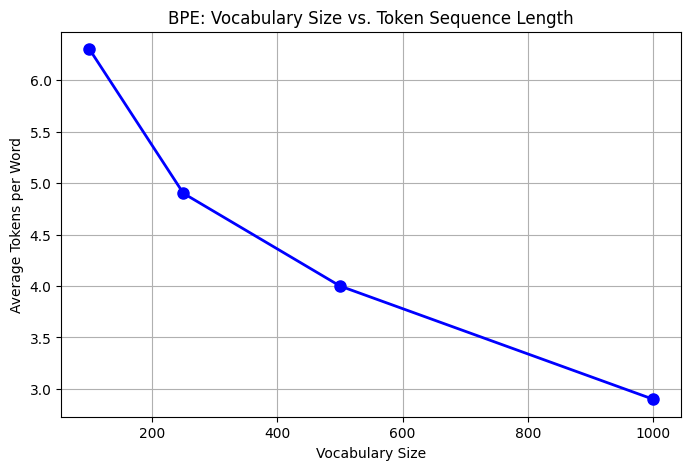


Vocabulary size experiment complete!


In [33]:
# Vocab size experiment
# Wrapped in try/except so a failure here doesn't break autograder import.

if __name__ == "__main__":
    try:
        #import matplotlib
        import matplotlib.pyplot as plt

        # vocab_sizes = (100, 250, 500, 1000, 2000, 3000, 5000)
        vocab_sizes = [100, 250, 500, 1000]   # Ran it only once with the long list, shorten for re-runs

        test_words_experiment = [
            "the", "running", "university", "tokenization",
            "internationalization", "neural", "transformer",
            "beautiful", "government", "understanding"
        ]

        avg_tokens = []
        for vs in vocab_sizes:
            print(f"Training BPE with vocab_size={vs}...")
            v, m, _ = train_bpe(word_freqs, base_vocab, target_vocab_size=vs)

            total_tokens = 0
            for w in test_words_experiment:
                tokens = bpe_tokenize(w, m)
                total_tokens += len(tokens)
            avg = total_tokens / len(test_words_experiment)
            avg_tokens.append(avg)
            print(f"  Vocab size: {len(v)}, Avg tokens per word: {avg:.2f}")

        # Plot the results
        plt.figure(figsize=(8, 5))
        plt.plot(vocab_sizes, avg_tokens, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Vocabulary Size')
        plt.ylabel('Average Tokens per Word')
        plt.title('BPE: Vocabulary Size vs. Token Sequence Length')
        plt.grid(True)
        plt.show()
        print("\nVocabulary size experiment complete!")

    except Exception as e:
        print(f"\u26a0\ufe0f  Vocab size experiment skipped: {type(e).__name__}: {e}")

# DWN ~  Result:
# Vocab size: 100, Avg tokens per word: 6.30
# Vocab size: 250, Avg tokens per word: 4.90
# Vocab size: 500, Avg tokens per word: 4.00
# Vocab size: 1000, Avg tokens per word: 2.90
# Vocab size: 2000, Avg tokens per word: 2.40
# Vocab size: 3000, Avg tokens per word: 2.20
# Vocab size: 5000, Avg tokens per word: 1.80

**[WRITEUP] Answer 3: Vocabulary Size Analysis (included in Problem 4.6's 5 points)**

Based on your plot:

1. Describe the shape of the curve. Is the relationship linear or does it show diminishing returns?
2. At what vocabulary size do you start seeing diminishing returns (i.e., adding more merges barely reduces tokens per word)?
3. GPT-2 uses ~50,000 BPE tokens and GPT-4 uses ~100,000. Based on your experiment, why might larger vocabularies be worthwhile despite the diminishing returns? What costs does a larger vocabulary incur? *(Hint: think about the embedding matrix size in a transformer.)*

---
### [WRITEUP] Answer 2: Normalization and Tokenization Interaction (4 points)

(*This question lives between Section 4 and Section 5 because it builds on your BPE implementation from Section 4 and the Porter Stemmer from Problem 3.1. Note: these 4 points count toward Section 3: Text Normalization's 10-point total.*)

This question explores how text normalization interacts with BPE tokenization. Now that you have a working BPE implementation, run the following experiment:

1. Apply the Porter Stemmer (from Problem 3.1) to every word in your BPE training corpus. Then re-run BPE training on the stemmed corpus (you can reuse your `train_bpe` function with a new `word_freqs` built from stemmed words).

2. In your writeup, compare:
   - How many unique tokens are in the original corpus vs. the stemmed corpus before BPE? (Count by tokenizing each document with `nltk_preprocess()`, applying the stemmer when relevant, and counting the size of the resulting vocabulary.)
   - How does the BPE vocabulary differ? Show **5 example merge rules** from the stemmed BPE that don't appear (or appear in a different order) in the unstemmed BPE.
   - Tokenize the words `"running"`, `"generalization"`, and `"universities"` with both the original and stemmed BPE. How do the tokenizations differ?

3. Would you prefer the stemmed or unstemmed BPE for:
   - A **search engine** (where "organize" and "organizing" should match the same documents)?
   - A **machine translation** system (where "organize" and "organizing" have different translations)?

   Explain your reasoning using specific observations from your experiment.


In [34]:
# Cell 56

if __name__ == "__main__":
    porter_s4 = PorterStemmer()
    # Stemming is *not injective* so multiple words from our corpus will become the same stem
    stem_count = Counter()
    for word, word_freq in word_freqs.items():  # Reusing our word-frequency dictionary from 4.1
        # Because `word` is a tuple of individual letters, need to convert it before stemming.
        stemmable = "".join(word)
        the_stem = porter_s4.stem(stemmable)
        # Now register in dict -- add its frequency, don't overwrite!
        stem_count[tuple(the_stem)] += word_freq  # Once more back to tuple of chars
    stem_freqs = dict(stem_count)  # Counter to dictionary
    print(f"The Porter stemmer turns the 5486 unique words of Simple English Wikipedia (excluding"
           f" those with frequency <50) into {len(stem_freqs)} unique stems.")

    # We could define "unique tokens" another way, but I'll use the way above for the BPE run:
    countr = Counter()
    for docu in corpus_docs:
        words_in_doc = nltk_preprocess(docu)   # We re-use this function which we wrote in Part 2
        # Apply the Porter Stemmer to every word, building a stem-frequency table
        stemmed_words_in_doc = [porter_s4.stem(term) for term in words_in_doc]
        # These are intact words, not tuples of chars
        countr.update(stemmed_words_in_doc) # Need to convert to tuples of chars
    # print("Discarding stems with frequency < 50.")
    stemmed_frequencies = {tuple(st): ct for st, ct in countr.items() if ct >= 50}
    print(f"When we apply the stemmer *before* truncating for frequency >= 50, we get a training"
           f" corpus of {len(stemmed_frequencies)} words.")
    # Output: Porter stemmer turns nltk.preprocess' 5486 unique words into 4109 unique stems.
    # But if applied *before* truncating for frequency, we start with 4670 unique stems.

    # Run BPE using as before, starting with a new word_freqs built from the stemmed corpus
    voc, stem_merge, _ = train_bpe(stem_freqs, base_vocab, 1000)
    # Only using one vocab size endpoint this time

# Difference in merge rules:
unstemmed_merges = set(merges) - set(stem_merge)  # merges still in scope from "train_bpe call" in section 4.5
print(unstemmed_merges)
# Merge rules that appear in a different order when training from the stemmed set:
overlap = set(merges).intersection(set(stem_merge))
unstem_mg_ordered = enumerate(merges)
stemmed_mg_ordered = enumerate(stem_merge)
# Sort the tuples in overlap by the difference of their indices in unstem_mg_ordered vs stemmed_mg_ordered
print(

The Porter stemmer turns the 5486 unique words of Simple English Wikipedia (excluding those with frequency <50) into 4109 unique stems.
When we apply the stemmer *before* truncating for frequency >= 50, we get a training corpus of 4670 words.
Vocabulary size 133 
Iteration 100 
Last few merges: [(('p', 're'), 'pre'), (('f', 'e'), 'fe'), (('s', 'on'), 'son'), (('at', 'e'), 'ate'), (('p', 'ol'), 'pol')]
Vocabulary size 233 
Iteration 200 
Last few merges: [(('writ', 'er'), 'writer'), (('m', 'on'), 'mon'), (('g', 're'), 'gre'), (('y', 'ear'), 'year'), (('sing', 'er'), 'singer')]
Vocabulary size 333 
Iteration 300 
Last few merges: [(('nor', 'th'), 'north'), (('li', 've'), 'live'), (('t', 'wo'), 'two'), (('ou', 'ld'), 'ould'), (('il', 'd'), 'ild')]
Vocabulary size 433 
Iteration 400 
Last few merges: [(('in', 't'), 'int'), (('an', 'n'), 'ann'), (('jan', 'u'), 'janu'), (('janu', 'ari'), 'januari'), (('ro', 'w'), 'row')]
Vocabulary size 533 
Iteration 500 
Last few merges: [(('lat', 'er'), '

---
## Section 5: Modern Tokenizers (10 points)

Your BPE implementation is the same algorithm used by real tokenizers like GPT-2's. But production tokenizers like GPT-4's (via the `tiktoken` library) are trained on much larger corpora with much larger vocabularies. In this section, you will compare your BPE to GPT-4's tokenizer.

**Lecture:** M02.1.11 | **Reference:** [tiktoken documentation](https://github.com/openai/tiktoken)

### Problem 5.1: Exploring tiktoken (4 points)

Use `tiktoken` to tokenize text with GPT-4's tokenizer (`cl100k_base` encoding). This tokenizer has a vocabulary of ~100,000 tokens, trained on a massive multilingual corpus.

Complete the function below to:
1. Encode text into token IDs using `enc.encode()`
2. Decode each token ID individually to see the actual subword tokens
3. Return both the token count and the list of decoded tokens

Then compare the tokenization of English text vs. non-English text to observe **multilingual tokenization bias**: languages underrepresented in training data are split into more tokens, making them more expensive to process.

In [35]:
def tiktoken_analyze(text: str, encoding_name: str = "cl100k_base") -> tuple:
    """Tokenize text using tiktoken and return analysis.

    Args:
        text: Text to tokenize.
        encoding_name: Name of the tiktoken encoding (default: GPT-4's encoding).

    Returns:
        A tuple of (num_tokens, token_strings) where:
            num_tokens: int, number of tokens
            token_strings: list of str, the decoded text for each token
    """
    enc = tiktoken.get_encoding(encoding_name)
    tokenlist = enc.encode(text)
    #  gives you a list of integer token IDs
    token_strings = []
    for token_id in set(tokenlist):
        token_strings.append(enc.decode(token_id))
    #  enc.decode([single_id]) decodes a single token ID back to a string

    return (len(tokenlist), token_strings)


In [36]:
# tiktoken multilingual comparison
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        # Compare English vs. non-English tokenization
        english_text = "The quick brown fox jumps over the lazy dog."
        spanish_text = "El rapido zorro marron salta sobre el perro perezoso."
        chinese_text = "快速的棕色狐狸跳过了懒狗。"  # Same meaning in Chinese
        arabic_text = "الثعلب البني السريع يقفز فوق الكلب الكسول."  # Same meaning in Arabic
        # DWN: Is the Arabic line displaying left-to-right or right-to-left?

        texts = {
            "English": english_text,
            "Spanish": spanish_text,
            "Chinese": chinese_text,
            "Arabic": arabic_text,
        }

        print("Multilingual Tokenization Comparison")
        print("=" * 70)
        for lang, text in texts.items():
            n_tokens, tokens = tiktoken_analyze(text)
            n_chars = len(text)
            ratio = n_chars / n_tokens
            print(f"\n{lang} ({n_chars} chars -> {n_tokens} tokens, {ratio:.1f} chars/token):")
            print(f"  Text: {text}")
            print(f"  Tokens: {tokens}")

        # Sanity check: tokenization should produce a reasonable number of tokens
        en_count, en_tokens = tiktoken_analyze(english_text)
        assert en_count > 0, "Should produce at least one token"
        assert isinstance(en_tokens, list), "Should return a list of token strings"

        print("\n" + "=" * 70)
        print("Notice: Non-English languages typically require more tokens for the")
        print("same content. This is because the BPE merges were learned primarily")
        print("from English text, so non-English character sequences are less likely")
        print("to have been merged into larger tokens.")
        print("\nSanity checks passed!")
    except Exception as e:
        print(f"\u26a0\ufe0f  tiktoken multilingual comparison skipped: {type(e).__name__}: {e}")


Multilingual Tokenization Comparison
⚠️  tiktoken multilingual comparison skipped: TypeError: 'int' object is not an instance of 'Sequence'


### Problem 5.2: Compare Your BPE to tiktoken (3 points)

Tokenize the following words with both your BPE implementation and tiktoken. Create a comparison table showing the differences.

Complete the function below, then answer the writeup question.

In [37]:
def compare_tokenizers(words: list, merges: list, encoding_name: str = "cl100k_base") -> list:
    """Compare BPE and tiktoken tokenization for a list of words.

    Args:
        words: List of words to tokenize.
        merges: Merge rules from your BPE training.
        encoding_name: tiktoken encoding name.

    Returns:
        A list of tuples: (word, bpe_tokens, tiktoken_tokens, bpe_count, tiktoken_count)
    """
    ## YOUR CODE HERE
    pass

In [38]:
# compare_tokenizers call
# Wrapped in try/except so a failure here doesn't break autograder import.
if __name__ == "__main__":
    try:
        comparison_words = [
            "the", "running", "university", "tokenization",
            "internationalization", "antidisestablishmentarianism",
            "chatgpt", "bpe", "neural", "transformer",
        ]

        results = compare_tokenizers(comparison_words, merges)

        print(f"{'Word':<30} {'Your BPE':<30} {'tiktoken (GPT-4)':<30} {'BPE #':<6} {'TT #':<6}")
        print("-" * 105)
        for word, bpe_tok, tt_tok, bpe_n, tt_n in results:
            bpe_str = str(bpe_tok)
            tt_str = str(tt_tok)
            print(f"{word:<30} {bpe_str:<30} {tt_str:<30} {bpe_n:<6} {tt_n:<6}")

        assert len(results) == len(comparison_words), "Should have one result per word"
        print("\nComparison complete!")
    except Exception as e:
        print(f"\u26a0\ufe0f  compare_tokenizers call skipped: {type(e).__name__}: {e}")


Word                           Your BPE                       tiktoken (GPT-4)               BPE #  TT #  
---------------------------------------------------------------------------------------------------------
⚠️  compare_tokenizers call skipped: TypeError: 'NoneType' object is not iterable


### [WRITEUP] Answer 4: Multilingual Tokenization Analysis (3 points)

Pick **one** of the following non-English sentences (or provide your own in a language you know):

| Language | Sentence | Translation |
|---|---|---|
| Turkish | "Çocuklar bahçede oynuyorlardı" | "The children were playing in the garden" |
| German | "Unabhängigkeitserklärungen sind wichtige historische Dokumente" | "Declarations of independence are important historical documents" |
| Finnish | "Tietokoneohjelmointi on mielenkiintoista ja haastavaa" | "Computer programming is interesting and challenging" |
| Arabic | "الطلاب يدرسون في المكتبة الجامعية" | "The students are studying in the university library" |

Tokenize the sentence with **both** your BPE and tiktoken. Then answer:

1. How many tokens does each tokenizer produce? Show the actual token lists.
2. Which tokenizer produces more tokens for this language, and why? Be specific — is it vocabulary size, training corpus, or something else?
3. For the language you chose, what **structural property** of that language (e.g., agglutination in Turkish, compounds in German, abjad script in Arabic) causes particularly inefficient tokenization? How could a tokenizer be designed to handle this language better?
4. What are the **fairness implications** of this tokenization gap for users of LLMs? *(Hint: more tokens = higher cost per query, shorter effective context window.)*


In [39]:
# multilingual tokenization analysis
if __name__ == "__main__":
  pass

---
## Section 6: Reflection (10 points) [WRITEUP]

**[WRITEUP] Answer 5: Tokenizer Design Challenge**

You are building a tokenizer for an **AI-powered code editor** that needs to handle Python, JavaScript, and natural language comments within code files. Your tokenizer will be used as the input to a language model that provides code completion and documentation generation.

Design the tokenizer by answering:

1. **Pre-tokenization rules** (4 points): Before applying BPE, what rules would you use to split the raw input? Consider:
   - How to handle **whitespace and indentation** (significant in Python!)
   - How to handle **operators and punctuation** (`+=`, `!=`, `=>`, `...`, `::`)
   - How to handle **string literals** and **comments** (should `"hello world"` be one token or split?)
   - How to handle **camelCase** and **snake_case** identifiers (`getUserName`, `get_user_name`)

2. **Special tokens** (3 points): What special tokens would you add to the vocabulary beyond BPE-learned tokens? Consider tokens for:
   - Code structure (indentation levels, newlines, end-of-file)
   - Language boundaries (switching between Python, JavaScript, natural language)
   - Common code patterns that should be single tokens

3. **Evaluation** (3 points): How would you measure whether your tokenizer is "good"? Propose two metrics — one measuring **efficiency** (token count) and one measuring **quality** (downstream task performance). How would you balance these?

*(There is no single correct answer. We are looking for thoughtful design reasoning that demonstrates understanding of tokenization principles from this module.)*

---
## Submission Checklist

Before submitting, verify:

- [ ] All code cells run without errors (Kernel -> Restart & Run All)
- [ ] All assertion/sanity checks pass
- [ ] `hw02_writeup.pdf` contains answers to all **[WRITEUP]** questions:
  - **Answer 1:** Regex URL design challenge (pattern, successes, failures)
  - **Answer 2:** Normalization-tokenization interaction (stemmed BPE experiment, search engine vs MT comparison)
  - **Answer 3:** Vocabulary size experiment (plot, diminishing returns analysis, GPT scaling)
  - **Answer 4:** BPE vs tiktoken multilingual comparison (non-English language analysis, fairness implications)
  - **Answer 5:** Code editor tokenizer design (pre-tokenization, special tokens, evaluation metrics)
- [ ] Files are named exactly: `hw02.ipynb`, `hw02.py`, `hw02_writeup.pdf`